# BaseAttentive: Attention Stack Configuration

This notebook demonstrates how to configure different attention mechanisms in the decoder.

In [1]:
# ── v2.2.0 Backend Setup ─────────────────────────────────────────────────────
# BASE_ATTENTIVE_BACKEND must be set *before* importing base_attentive.
# Choose your installed backend: "tensorflow" | "torch" | "jax" | "auto"
import os
os.environ.setdefault("BASE_ATTENTIVE_BACKEND", "tensorflow")
os.environ.setdefault("KERAS_BACKEND", os.environ["BASE_ATTENTIVE_BACKEND"])
import keras  # initialise Keras 3 backend before base_attentive
BACKEND = os.environ["BASE_ATTENTIVE_BACKEND"]
print(f"Backend: {BACKEND}")

Backend: tensorflow


In [2]:
from base_attentive import BaseAttentive

## Available Attention Mechanisms

1. **Cross-Attention**: Allows decoder to focus on encoder outputs
2. **Hierarchical Attention**: Self-attention within decoder for structure finding
3. **Memory-Augmented Attention**: Long-term memory retrieval mechanism

In [3]:
# Base configuration
base_config = {
    "static_input_dim": 4,
    "dynamic_input_dim": 8,
    "future_input_dim": 6,
    "output_dim": 1,
    "forecast_horizon": 24,
}

print("✅ Base configuration prepared")

✅ Base configuration prepared


## Configuration 1: Cross Attention Only

Simple encoder-decoder attention without self-attention.

In [4]:
cross_only = {
    **base_config,
    "architecture_config": {
        "decoder_attention_stack": ["cross"],
    },
    "name": "CrossAttentionOnly",
}

model1 = BaseAttentive(**cross_only)

print("🔍 Model 1: Cross Attention Only")
print(
    f"  Attention Stack: {model1.architecture_config['decoder_attention_stack']}"
)
print("  Complexity: Low")
print("  Best for: Simple encoder-decoder interactions")

D:\projects\base-attentive\src\base_attentive\core\base_attentive.py:148: DeprecatedParameterWarning: BaseAttentive: 'static_input_dim' is deprecated since 2.1.0 and will be removed in 3.0.0. Use 'static_dim' instead.
  resolved = resolve_deprecated_kwargs(
D:\projects\base-attentive\src\base_attentive\core\base_attentive.py:148: DeprecatedParameterWarning: BaseAttentive: 'dynamic_input_dim' is deprecated since 2.1.0 and will be removed in 3.0.0. Use 'dynamic_dim' instead.
  resolved = resolve_deprecated_kwargs(
D:\projects\base-attentive\src\base_attentive\core\base_attentive.py:148: DeprecatedParameterWarning: BaseAttentive: 'future_input_dim' is deprecated since 2.1.0 and will be removed in 3.0.0. Use 'future_dim' instead.
  resolved = resolve_deprecated_kwargs(


🔍 Model 1: Cross Attention Only
  Attention Stack: ['cross']
  Complexity: Low
  Best for: Simple encoder-decoder interactions


## Configuration 2: Cross + Hierarchical Attention

Encoder-decoder attention followed by self-attention within decoder.

In [5]:
cross_hierarchical = {
    **base_config,
    "architecture_config": {
        "decoder_attention_stack": ["cross", "hierarchical"],
    },
    "name": "CrossHierarchical",
}

model2 = BaseAttentive(**cross_hierarchical)

print("🔍 Model 2: Cross + Hierarchical Attention")
print(
    f"  Attention Stack: {model2.architecture_config['decoder_attention_stack']}"
)
print("  Complexity: Medium")
print(
    "  Best for: Multi-horizon forecasts with structural patterns"
)

🔍 Model 2: Cross + Hierarchical Attention
  Attention Stack: ['cross', 'hierarchical']
  Complexity: Medium
  Best for: Multi-horizon forecasts with structural patterns


## Configuration 3: Full Stack (All Attention Types)

Cross, Hierarchical, and Memory-Augmented attention combined.

In [6]:
full_stack = {
    **base_config,
    "architecture_config": {
        "decoder_attention_stack": [
            "cross",
            "hierarchical",
            "memory",
        ],
    },
    "memory_size": 128,  # Memory buffer size
    "name": "FullAttentionStack",
}

model3 = BaseAttentive(**full_stack)

print("🔍 Model 3: Full Attention Stack")
print(
    f"  Attention Stack: {model3.architecture_config['decoder_attention_stack']}"
)
print(f"  Memory Size: {model3.memory_size}")
print("  Complexity: High")
print(
    "  Best for: Complex long-term dependencies, recall mechanisms"
)

🔍 Model 3: Full Attention Stack
  Attention Stack: ['cross', 'hierarchical', 'memory']
  Memory Size: 128
  Complexity: High
  Best for: Complex long-term dependencies, recall mechanisms


## Configuration 4: Custom Ordering

You can specify the order of attention mechanisms.

In [7]:
# Memory first, then cross attention (unusual but possible)
custom_order = {
    **base_config,
    "architecture_config": {
        "decoder_attention_stack": [
            "memory",
            "cross",
            "hierarchical",
        ],
    },
    "memory_size": 100,
    "name": "CustomOrderAttention",
}

model4 = BaseAttentive(**custom_order)

print("🎨 Model 4: Custom Attention Order")
print(
    f"  Attention Stack: {model4.architecture_config['decoder_attention_stack']}"
)
print(
    "  Note: Order matters! First layer uses input, others chain the output"
)

🎨 Model 4: Custom Attention Order
  Attention Stack: ['memory', 'cross', 'hierarchical']
  Note: Order matters! First layer uses input, others chain the output


## Comparison: Attention Configurations

In [8]:
import pandas as pd

attention_comparison = {
    "Configuration": [
        "Cross Only",
        "Cross + Hierarchical",
        "Full Stack",
        "Custom Order",
    ],
    "Stack": [
        "['cross']",
        "['cross', 'hierarchical']",
        "['cross', 'hierarchical', 'memory']",
        "['memory', 'cross', 'hierarchical']",
    ],
    "Parameters": ["Low", "Medium", "High", "High"],
    "Training Time": ["Fast", "Medium", "Slow", "Slow"],
    "Best Use Case": [
        "Simple forecasting",
        "Structured horizons",
        "Complex patterns",
        "Specialized tasks",
    ],
}

df = pd.DataFrame(attention_comparison)
print(df.to_string(index=False))

       Configuration                               Stack Parameters Training Time       Best Use Case
          Cross Only                           ['cross']        Low          Fast  Simple forecasting
Cross + Hierarchical           ['cross', 'hierarchical']     Medium        Medium Structured horizons
          Full Stack ['cross', 'hierarchical', 'memory']       High          Slow    Complex patterns
        Custom Order ['memory', 'cross', 'hierarchical']       High          Slow   Specialized tasks


## Attention Mechanisms Explained

In [9]:
mechanisms = {
    "Cross-Attention": {
        "Role": "Queries (decoder) attend to Keys/Values (encoder)",
        "Purpose": "Bridge encoder-decoder, extract relevant context",
        "When to use": "Always (fundamental for seq2seq)",
        "Complexity": "O(n*m) where n=decoder len, m=encoder len",
    },
    "Hierarchical Attention": {
        "Role": "Self-attention within decoder outputs",
        "Purpose": "Find patterns and structure in predictions",
        "When to use": "When temporal structure matters (seasonality, trends)",
        "Complexity": "O(n²) where n=decoder length",
    },
    "Memory-Augmented Attention": {
        "Role": "Retrieve from external memory buffer",
        "Purpose": "Store and recall long-term patterns",
        "When to use": "When data has recurring patterns or long-term deps",
        "Complexity": "O(n*k) where k=memory size",
    },
}

for name, details in mechanisms.items():
    print(f"\n{name}:")
    print("─" * 50)
    for key, value in details.items():
        print(f"  {key:.<20} {value}")


Cross-Attention:
──────────────────────────────────────────────────
  Role................ Queries (decoder) attend to Keys/Values (encoder)
  Purpose............. Bridge encoder-decoder, extract relevant context
  When to use......... Always (fundamental for seq2seq)
  Complexity.......... O(n*m) where n=decoder len, m=encoder len

Hierarchical Attention:
──────────────────────────────────────────────────
  Role................ Self-attention within decoder outputs
  Purpose............. Find patterns and structure in predictions
  When to use......... When temporal structure matters (seasonality, trends)
  Complexity.......... O(n²) where n=decoder length

Memory-Augmented Attention:
──────────────────────────────────────────────────
  Role................ Retrieve from external memory buffer
  Purpose............. Store and recall long-term patterns
  When to use......... When data has recurring patterns or long-term deps
  Complexity.......... O(n*k) where k=memory size


## Training Attention Configurations

We train two representative stacks on the same data to empirically compare their fit quality:

- **Cross Only** — lightweight baseline
- **Full Stack** (cross + hierarchical + memory) — maximum expressiveness

In [10]:
import numpy as np
import keras

np.random.seed(0)
N, T, H = 64, 16, 24
S_DIM, D_DIM, F_DIM = 4, 8, 6

# ── Synthetic data ────────────────────────────────────────────────────
t_past   = np.linspace(0, 4*np.pi, T)
t_future = np.linspace(4*np.pi, 6*np.pi, H)
static_d  = np.random.randn(N, S_DIM).astype('float32')
dynamic_d = (np.tile(np.sin(t_past),   (N,1))[:,:,None]
             + 0.1*np.random.randn(N,T,D_DIM)).astype('float32')
future_d  = (np.tile(np.cos(t_future), (N,1))[:,:,None]
             + 0.1*np.random.randn(N,H,F_DIM)).astype('float32')
target_d  = (np.tile(np.sin(t_future), (N,1))[:,:,None]
             + 0.1*np.random.randn(N,H,1)).astype('float32')

print(f'static:{static_d.shape} dynamic:{dynamic_d.shape} future:{future_d.shape} target:{target_d.shape}')

static:(64, 4) dynamic:(64, 16, 8) future:(64, 24, 6) target:(64, 24, 1)


In [11]:
from base_attentive import BaseAttentive

def build_and_train(stack, label, memory_size=None, epochs=12):
    cfg = {'decoder_attention_stack': stack}
    kw  = dict(memory_size=memory_size) if memory_size else {}
    m   = BaseAttentive(
        static_input_dim=S_DIM, dynamic_input_dim=D_DIM,
        future_input_dim=F_DIM, output_dim=1, forecast_horizon=H,
        architecture_config=cfg, **kw,
    )
    _ = m([static_d, dynamic_d, future_d])  # build weights
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
    h = m.fit([static_d, dynamic_d, future_d], target_d,
              epochs=epochs, batch_size=16, validation_split=0.2, verbose=0)
    print(f'{label:45s}  val_MSE={h.history["val_loss"][-1]:.4f}')
    return m, h

print('Training...')
m_cross, h_cross = build_and_train(['cross'],                          'Cross Only')
m_full,  h_full  = build_and_train(['cross','hierarchical','memory'],  'Full Stack (cross+hierarchical+memory)', memory_size=64)
print('Done.')

Training...


D:\projects\base-attentive\src\base_attentive\core\base_attentive.py:148: DeprecatedParameterWarning: BaseAttentive: 'static_input_dim' is deprecated since 2.1.0 and will be removed in 3.0.0. Use 'static_dim' instead.
  resolved = resolve_deprecated_kwargs(
D:\projects\base-attentive\src\base_attentive\core\base_attentive.py:148: DeprecatedParameterWarning: BaseAttentive: 'dynamic_input_dim' is deprecated since 2.1.0 and will be removed in 3.0.0. Use 'dynamic_dim' instead.
  resolved = resolve_deprecated_kwargs(
D:\projects\base-attentive\src\base_attentive\core\base_attentive.py:148: DeprecatedParameterWarning: BaseAttentive: 'future_input_dim' is deprecated since 2.1.0 and will be removed in 3.0.0. Use 'future_dim' instead.
  resolved = resolve_deprecated_kwargs(


Cross Only                                     val_MSE=0.0195
Full Stack (cross+hierarchical+memory)         val_MSE=0.0202
Done.


## Plot 1 — Convergence Comparison

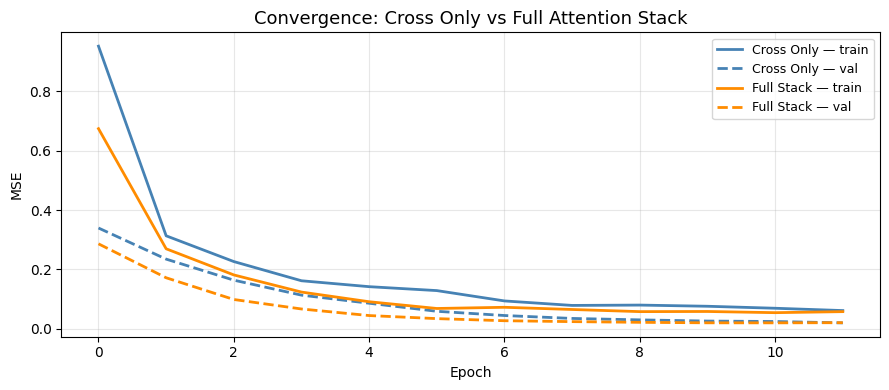

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
for h, label, color, ls in [
    (h_cross, 'Cross Only — train',     'steelblue',   '-'),
    (h_cross, 'Cross Only — val',        'steelblue',   '--'),
    (h_full,  'Full Stack — train',      'darkorange',  '-'),
    (h_full,  'Full Stack — val',         'darkorange',  '--'),
]:
    key = 'loss' if 'train' in label else 'val_loss'
    ax.plot(h.history[key], label=label, color=color, linestyle=ls, linewidth=2)

ax.set_title('Convergence: Cross Only vs Full Attention Stack', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Plot 2 — Forecast Quality per Configuration

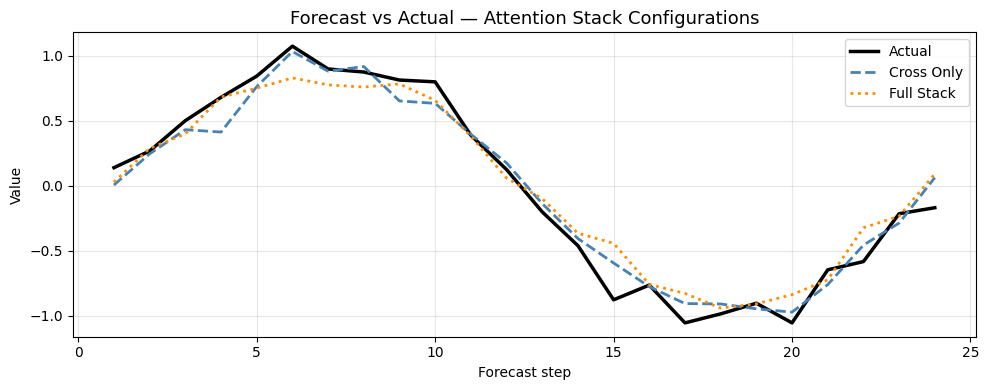

Cross Only  MAE: 0.1053
Full Stack  MAE: 0.1090


In [13]:
test_sl = slice(-10, None)
pred_cross = m_cross.predict([static_d[test_sl], dynamic_d[test_sl], future_d[test_sl]], verbose=0)
pred_full  = m_full.predict( [static_d[test_sl], dynamic_d[test_sl], future_d[test_sl]], verbose=0)

sample = 0
steps  = np.arange(1, H + 1)
actual = target_d[test_sl][sample, :, 0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps, actual,                   label='Actual',       color='black',      linewidth=2.5)
ax.plot(steps, pred_cross[sample, :, 0], label='Cross Only',   color='steelblue',  linewidth=2, linestyle='--')
ax.plot(steps, pred_full [sample, :, 0], label='Full Stack',   color='darkorange', linewidth=2, linestyle=':')

ax.set_title('Forecast vs Actual — Attention Stack Configurations', fontsize=13)
ax.set_xlabel('Forecast step')
ax.set_ylabel('Value')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

mae_cross = float(np.mean(np.abs(pred_cross - target_d[test_sl])))
mae_full  = float(np.mean(np.abs(pred_full  - target_d[test_sl])))
print(f'Cross Only  MAE: {mae_cross:.4f}')
print(f'Full Stack  MAE: {mae_full:.4f}')

## Plot 3 — MAE Bar Chart

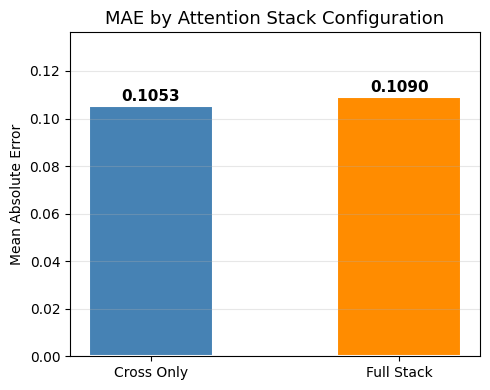

In [14]:
labels = ['Cross Only', 'Full Stack']
maes   = [mae_cross, mae_full]
colors = ['steelblue', 'darkorange']

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, maes, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.001, f'{v:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('MAE by Attention Stack Configuration', fontsize=13)
ax.set_ylabel('Mean Absolute Error')
ax.set_ylim(0, max(maes) * 1.25)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Recommendation Guide

**Choose based on your data characteristics:**

- **Simple Forecasting** → Use Cross-Attention only
- **Seasonal/Trend Pattern** → Use Cross + Hierarchical
- **Complex Multi-scale** → Use Full Stack
- **Limited Memory/Speed** → Use Cross-Attention or Cross+Hierarchical